In [1]:
import os
import math
import time
import random
from dataclasses import dataclass
from typing import List, Dict, Tuple, Optional
from PIL import Image

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split, Subset

import torchvision
from torchvision import transforms
from torchvision.models import resnet18, ResNet18_Weights

print("torch:", torch.__version__)
print("torchvision:", torchvision.__version__)

torch: 2.10.0+cpu
torchvision: 0.25.0+cpu


In [2]:
def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

RANDOM_STATE = 42
set_seed(RANDOM_STATE)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

FAST_MODE = True
DATA_DIR = "./data"

BATCH_SIZE = 64  # ResNet тяжелее, чем SimpleCNN
EPOCHS_HEAD = 4 if FAST_MODE else 8
EPOCHS_FT   = 4 if FAST_MODE else 8
EPOCHS = 5 if FAST_MODE else 12

Device: cpu


In [3]:
def get_resnet18_weights():
    # Пытаемся взять предобученные веса. Если не получилось – вернем None.
    try:
        w = ResNet18_Weights.DEFAULT
        # иногда ошибка возникает не здесь, а при фактической загрузке весов;
        # но на практике этого достаточно как "правильный путь".
        return w
    except Exception as e:
        print("Не удалось получить веса ResNet18_Weights.DEFAULT. Причина:", repr(e))
        return None

weights = get_resnet18_weights()
print("weights:", weights)

weights: ResNet18_Weights.IMAGENET1K_V1


In [4]:
# mean/std для нормализации (стандартные ImageNet)
STL10_MEAN = (0.485, 0.456, 0.406)
STL10_STD  = (0.229, 0.224, 0.225)
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)

IMG_SIZE = 224

train_tf = transforms.Compose([
    transforms.Resize(IMG_SIZE + 32),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(STL10_MEAN, STL10_STD),
])

eval_tf = transforms.Compose([
    transforms.Resize(IMG_SIZE + 32),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(STL10_MEAN, STL10_STD),
])

def load_stl10_tl(data_dir: str = DATA_DIR, val_split: float = 0.2, seed: int = 42):
    """
    Загрузка STL10 с разделением train на train/val.
    val_split: доля val в train (0.2 = 80/20)
    """
    # Фиксируем seed для воспроизводимости
    torch.manual_seed(seed)
    np.random.seed(seed)
    
    # Загружаем train с аугментациями и без
    ds_train_aug  = torchvision.datasets.STL10(root=data_dir, split='train', 
                                              download=True, transform=train_tf)
    ds_train_eval = torchvision.datasets.STL10(root=data_dir, split='train', 
                                              download=True, transform=eval_tf)
    
    # Загружаем test
    ds_test = torchvision.datasets.STL10(root=data_dir, split='test', 
                                        download=True, transform=eval_tf)
    
    # Создаем индексы для разделения train (5000 образцов)
    n_train = len(ds_train_aug)
    n_val = int(n_train * val_split)
    n_train_final = n_train - n_val
    
    indices = list(range(n_train))
    np.random.shuffle(indices)
    
    train_idx = indices[:n_train_final]
    val_idx = indices[n_train_final:]
    
    # Создаем подмножества
    ds_train_aug_final = Subset(ds_train_aug, train_idx)
    ds_train_eval_final = Subset(ds_train_eval, train_idx)
    ds_val = Subset(ds_train_eval, val_idx)
    
    print(f"Train full: {n_train}")
    print(f"Train final: {len(ds_train_aug_final)} (80%)")
    print(f"Val: {len(ds_val)} (20%)")
    print(f"Test: {len(ds_test)}")
    
    return ds_train_aug_final, ds_train_eval_final, ds_val, ds_test

# Загружаем данные
ds_train_aug, ds_train_eval, ds_val, ds_test = load_stl10_tl()
class_names = ds_train_aug.dataset.classes
print("Class names:", class_names)


Train full: 5000
Train final: 4000 (80%)
Val: 1000 (20%)
Test: 8000
Class names: ['airplane', 'bird', 'car', 'cat', 'deer', 'dog', 'horse', 'monkey', 'ship', 'truck']


In [5]:
def make_loaders_tl(
    ds_train_aug,
    ds_train_eval,
    ds_test,
    batch_size: int = BATCH_SIZE,
    val_ratio: float = 0.2,
    seed: int = RANDOM_STATE,
    fast_mode: bool = FAST_MODE,
):
    n_total = len(ds_train_aug)
    n_val = int(n_total * val_ratio)

    rng = np.random.RandomState(seed)
    indices = np.arange(n_total)
    rng.shuffle(indices)

    val_idx = indices[:n_val]
    train_idx = indices[n_val:]

    ds_train = Subset(ds_train_aug, train_idx)
    ds_val   = Subset(ds_train_eval, val_idx)

    if fast_mode:
        train_idx2 = rng.choice(len(ds_train), size=min(4000, len(ds_train)), replace=False)
        val_idx2   = rng.choice(len(ds_val), size=min(1000, len(ds_val)), replace=False)
        test_idx2  = rng.choice(len(ds_test), size=min(1000, len(ds_test)), replace=False)

        ds_train = Subset(ds_train, train_idx2)
        ds_val   = Subset(ds_val, val_idx2)
        ds_test_small = Subset(ds_test, test_idx2)
    else:
        ds_test_small = ds_test

    train_loader = DataLoader(ds_train, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
    val_loader   = DataLoader(ds_val, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
    test_loader  = DataLoader(ds_test_small, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

    return train_loader, val_loader, test_loader

train_loader, val_loader, test_loader = make_loaders_tl(ds_train_aug, ds_train_eval, ds_test)

x, y = next(iter(train_loader))
print("x:", x.shape, x.dtype)
print("y:", y.shape, y.dtype)

C:\Users\Mi\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\utils\data\dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


x: torch.Size([64, 3, 224, 224]) torch.float32
y: torch.Size([64]) torch.int64


In [6]:
# 2) Конфигурация
@dataclass
class RunConfig:
    data_dir: str = "./data"
    fast_mode: bool = True
    n_show: int = 4                 # сколько примеров визуализируем
    score_thr: float = 0.6          # порог по score для предсказаний
    iou_thr: float = 0.5            # порог IoU для TP/FP/FN
    model_name: str = "fasterrcnn_mobilenet_v3_large_fpn"  # быстрее на CPU
    # варианты: "fasterrcnn_resnet50_fpn_v2", "retinanet_resnet50_fpn_v2", ...

cfg = RunConfig()
cfg

RunConfig(data_dir='./data', fast_mode=True, n_show=4, score_thr=0.6, iou_thr=0.5, model_name='fasterrcnn_mobilenet_v3_large_fpn')

In [7]:
# 3) Данные: Oxford-IIIT Pet (download/unzip при необходимости)

OXFORD_URLS = {
    'images': 'http://www.robots.ox.ac.uk/~vgg/data/pets/data/images.tar.gz',
    'annotations': 'http://www.robots.ox.ac.uk/~vgg/data/pets/data/annotations.tar.gz'
}

def ensure_oxford(root: str) -> str:
    '''
    Гарантируем наличие папки root/oxford.
    Возвращаем путь к oxford.
    '''
    oxford_root = os.path.join(root, "oxford")
    if os.path.isdir(oxford_root):
        return oxford_root

    os.makedirs(root, exist_ok=True)

    # Скачивание через torchvision утилиту (если доступно)
    try:
        import torchvision
        from torchvision.datasets.utils import download_and_extract_archive
        import tarfile
        
        print("Downloading Oxford-IIIT Pet to:", root)
        
        # Скачиваем images
        images_path = os.path.join(root, "images.tar.gz")
        download_and_extract_archive(OXFORD_URLS['images'], download_root=root, 
                                   filename="images.tar.gz", remove_finished=False)
        
        # Скачиваем annotations
        download_and_extract_archive(OXFORD_URLS['annotations'], download_root=root, 
                                   filename="annotations.tar.gz", remove_finished=False)
        
        # Перемещаем в oxford/
        import shutil
        if os.path.exists(os.path.join(root, "images")):
            shutil.move(os.path.join(root, "images"), oxford_root)
        if os.path.exists(os.path.join(root, "annotations")):
            shutil.move(os.path.join(root, "annotations"), oxford_root)
        
        # Удаляем временные архивы
        for archive in ["images.tar.gz", "annotations.tar.gz"]:
            archive_path = os.path.join(root, archive)
            if os.path.exists(archive_path):
                os.remove(archive_path)
                
        if not os.path.isdir(oxford_root):
            raise FileNotFoundError("После распаковки не найдено oxford/. Проверьте содержимое папки ./data")
        return oxford_root
    except Exception as e:
        print("Не удалось автоматически скачать датасет.")
        print("Ошибка:", repr(e))
        print("\\nВариант вручную:")
        print(f"1) скачайте:")
        print(f"   {OXFORD_URLS['images']}")
        print(f"   {OXFORD_URLS['annotations']}")
        print(f"2) распакуйте так, чтобы было: {oxford_root}/images и {oxford_root}/annotations")
        raise

oxford_root = ensure_oxford(cfg.data_dir)
oxford_root


'./data\\oxford'

In [8]:
def count_trainable_params(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def build_resnet18(num_classes: int = 10, weights=weights) -> nn.Module:
    # Внимание: реальная загрузка весов может требовать интернет.
    # Если не получается – используйте weights=None.
    try:
        model = resnet18(weights=weights)
    except Exception as e:
        print("Не удалось загрузить предобученные веса. Переходим на weights=None. Причина:", repr(e))
        model = resnet18(weights=None)

    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model

def set_requires_grad(module: nn.Module, flag: bool) -> None:
    for p in module.parameters():
        p.requires_grad = flag

model = build_resnet18(num_classes=10, weights=weights).to(DEVICE)
print(model)
print("Trainable params:", count_trainable_params(model))

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

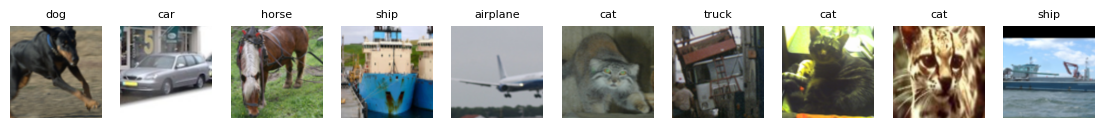

In [9]:
def denorm_STL10(x: torch.Tensor) -> torch.Tensor:
    # x: (C,H,W), нормализованный
    mean = torch.tensor(STL10_MEAN).view(3, 1, 1)
    std = torch.tensor(STL10_STD).view(3, 1, 1)
    return x * std + mean

@torch.no_grad()
def show_images(loader, n: int = 10) -> None:
    x, y = next(iter(loader))
    x = x[:n].cpu()
    y = y[:n].cpu()

    plt.figure(figsize=(14, 2))
    for i in range(n):
        plt.subplot(1, n, i + 1)
        img = denorm_STL10(x[i]).clamp(0, 1).permute(1, 2, 0).numpy()
        plt.imshow(img)
        plt.title(class_names[y[i].item()], fontsize=8)
        plt.axis("off")
    plt.show()

show_images(train_loader, n=10)

In [10]:
INPUT_DIM = 96 * 96 * 3
NUM_CLASSES = 10

class MLP(nn.Module):
    def __init__(self, input_dim: int, num_classes: int, hidden1: int = 1024, hidden2: int = 512):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden1),
            nn.ReLU(),
            nn.Linear(hidden1, hidden2),
            nn.ReLU(),
            nn.Linear(hidden2, num_classes),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: (B,C,H,W) -> (B, C*H*W)
        x = x.view(x.size(0), -1)
        return self.net(x)

def count_params(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

mlp = MLP(INPUT_DIM, NUM_CLASSES).to(DEVICE)
print(mlp)
print("Trainable params:", count_params(mlp))

MLP(
  (net): Sequential(
    (0): Linear(in_features=27648, out_features=1024, bias=True)
    (1): ReLU()
    (2): Linear(in_features=1024, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=10, bias=True)
  )
)
Trainable params: 28842506


In [11]:
def log_experiment(
    experiment_id: str,
    task: str,
    dataset: str,
    seed: int,
    model_summary: str,
    optimizer: str,
    lr: float,
    epochs_trained: int,
    best_val_accuracy: float = None,
    test_accuracy: float = None,
    precision: float = None,
    recall: float = None,
    mean_iou: float = None,
    notes: str = ""
):
    """
    Минимальная функция логирования экспериментов в runs.csv
    """
    experiment_data = {
        'experiment_id': experiment_id,
        'task': task,
        'dataset': dataset,
        'seed': seed,
        'model_summary': model_summary,
        'optimizer': optimizer,
        'lr': lr,
        'epochs_trained': epochs_trained,
        'best_val_accuracy': best_val_accuracy,
        'test_accuracy': test_accuracy,
        'precision': precision,
        'recall': recall,
        'mean_iou': mean_iou,
        'notes': notes
    }
    
    runs_file = 'artifacts/runs.csv'
    if os.path.exists(runs_file):
        df_existing = pd.read_csv(runs_file)
        df_new = pd.DataFrame([experiment_data])
        df_final = pd.concat([df_existing, df_new], ignore_index=True)
    else:
        df_final = pd.DataFrame([experiment_data])
    
    # Сохраняем
    df_final.to_csv(runs_file, index=False)
    print(f"[{experiment_id}] Сохранено в runs.csv")
    
    return df_final

In [12]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes: int = 10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),   # 224x224 -> 224x224
            nn.ReLU(), nn.MaxPool2d(2),                   # -> 112x112

            nn.Conv2d(32, 64, kernel_size=3, padding=1),  # 112x112 -> 112x112  
            nn.ReLU(), nn.MaxPool2d(2),                   # -> 56x56

            nn.Conv2d(64, 128, kernel_size=3, padding=1), # 56x56 -> 56x56
            nn.ReLU(), nn.MaxPool2d(2),                   # -> 28x28

            nn.Conv2d(128, 256, kernel_size=3, padding=1),# 28x28 -> 28x28
            nn.ReLU(), nn.MaxPool2d(2),                   # -> 14x14

            nn.Conv2d(256, 512, kernel_size=3, padding=1),# 14x14 -> 14x14
            nn.ReLU(), nn.MaxPool2d(2),                   # -> 7x7
        )

        # 512 * 7 * 7 = 25088
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512 * 7 * 7, 1024),  # 25088 → 1024
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(1024, num_classes),
        )
        
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.features(x)
        x = self.classifier(x)
        return x


cnn = SimpleCNN(NUM_CLASSES).to(DEVICE)
print(cnn)
print("Trainable params:", count_params(cnn))

SimpleCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (9): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(256, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU()
    (14): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (

In [13]:

def accuracy_from_logits(logits: torch.Tensor, y_true: torch.Tensor) -> float:
    preds = torch.argmax(logits, dim=1)
    return (preds == y_true).float().mean().item()

def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, total_correct, total_seen = 0.0, 0, 0

    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)

        optimizer.zero_grad(set_to_none=True)
        logits = model(x)
        loss = criterion(logits, y)

        if not torch.isfinite(loss):
            return float("nan"), float("nan")

        loss.backward()
        optimizer.step()

        bs = y.size(0)
        total_loss += loss.item() * bs
        total_correct += (torch.argmax(logits, dim=1) == y).sum().item()
        total_seen += bs

    return total_loss / total_seen, total_correct / total_seen

@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, total_correct, total_seen = 0.0, 0, 0

    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        logits = model(x)
        loss = criterion(logits, y)

        if not torch.isfinite(loss):
            return float("nan"), float("nan")

        bs = y.size(0)
        total_loss += loss.item() * bs
        total_correct += (torch.argmax(logits, dim=1) == y).sum().item()
        total_seen += bs

    return total_loss / total_seen, total_correct / total_seen

def fit(model, train_loader, val_loader, optimizer, criterion, epochs: int = 5, verbose: bool = True):
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

    for epoch in range(1, epochs + 1):
        t0 = time.time()
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion)
        va_loss, va_acc = evaluate(model, val_loader, criterion)

        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_loss"].append(va_loss)
        history["val_acc"].append(va_acc)

        dt = time.time() - t0
        if verbose:
            print(
                f"Epoch {epoch:02d}/{epochs} | "
                f"train loss {tr_loss:.4f}, acc {tr_acc:.3f} | "
                f"val loss {va_loss:.4f}, acc {va_acc:.3f} | {dt:.1f}s"
            )

        if (not math.isfinite(tr_loss)) or (not math.isfinite(va_loss)):
            print("NaN/Inf в loss – обычно это признак проблем с LR/стабильностью. Останавливаем обучение.")
            break

    return history

def plot_history(hist: Dict[str, List[float]], title: str = "") -> None:
    epochs = list(range(1, len(hist["train_loss"]) + 1))

    plt.figure(figsize=(10, 4))
    plt.plot(epochs, hist["train_loss"], label="train loss")
    plt.plot(epochs, hist["val_loss"], label="val loss")
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.title(title + " | loss")
    plt.grid(True)
    plt.legend()
    plt.show()

    plt.figure(figsize=(10, 4))
    plt.plot(epochs, hist["train_acc"], label="train acc")
    plt.plot(epochs, hist["val_acc"], label="val acc")
    plt.xlabel("epoch")
    plt.ylabel("accuracy")
    plt.title(title + " | accuracy")
    plt.grid(True)
    plt.legend()
    plt.show()

In [14]:
# Быстрый sanity-check по shape
with torch.no_grad():
    x_test = torch.randn(2, 3, 224, 224).to(DEVICE)
    print(f"Test: {x_test.shape} → {cnn(x_test).shape}")
    print(f"After features: {cnn.features(x_test).view(2, -1).shape}")


Test: torch.Size([2, 3, 224, 224]) → torch.Size([2, 10])
After features: torch.Size([2, 25088])



Experiment CNN_simple | lr=0.001 weight_decay=0.0 epochs=5
Trainable params: 27269962
Epoch 01/5 | train loss 2.0757, acc 0.237 | val loss 1.7793, acc 0.329 | 74.9s
Epoch 02/5 | train loss 1.7280, acc 0.346 | val loss 1.5881, acc 0.376 | 73.2s
Epoch 03/5 | train loss 1.5783, acc 0.404 | val loss 1.4646, acc 0.446 | 78.3s
Epoch 04/5 | train loss 1.4617, acc 0.438 | val loss 1.4622, acc 0.438 | 80.1s
Epoch 05/5 | train loss 1.4197, acc 0.464 | val loss 1.3727, acc 0.486 | 77.7s


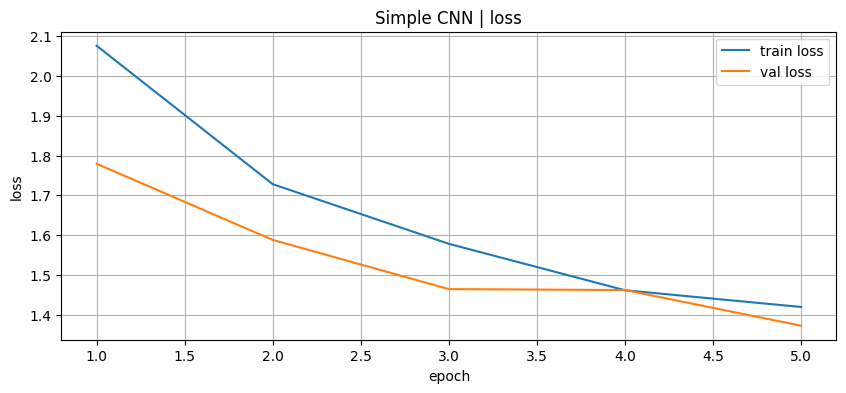

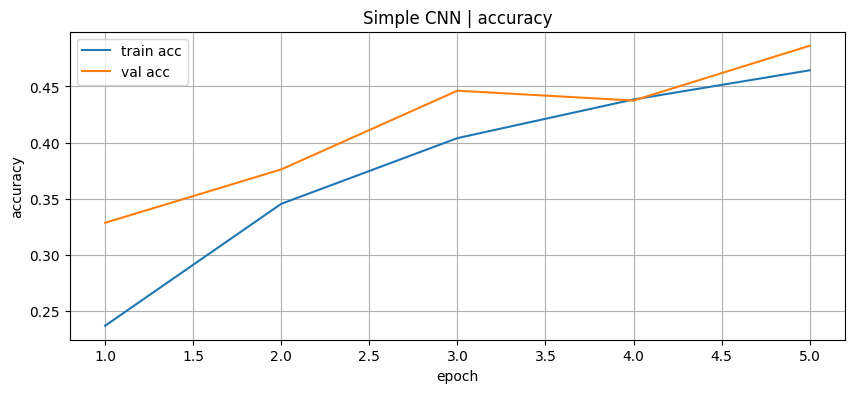

Best val acc: 0.486


In [15]:
criterion = nn.CrossEntropyLoss()

def run_experiment(exp_id: str, model: nn.Module, lr: float = 1e-3, weight_decay: float = 0.0, epochs: int = EPOCHS):
    model = model.to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    print("\n" + "=" * 80)
    print(f"Experiment {exp_id} | lr={lr} weight_decay={weight_decay} epochs={epochs}")
    print("Trainable params:", count_params(model))

    hist = fit(model, train_loader, val_loader, optimizer, criterion, epochs=epochs, verbose=True)
    best_val_acc = float(np.nanmax(hist["val_acc"])) if len(hist["val_acc"]) else float("nan")

    return {"exp_id": exp_id, "model": model, "history": hist, "best_val_acc": best_val_acc}

res_cnn = run_experiment("CNN_simple", SimpleCNN(NUM_CLASSES), lr=1e-3, epochs=EPOCHS)
plot_history(res_cnn["history"], title="Simple CNN")
print(f"Best val acc: {res_cnn['best_val_acc']:.3f}")

In [16]:
import torchvision.transforms as transforms

# C1: базовая без аугментаций (как было)
base_tf = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# C2: с аугментациями
train_tf = transforms.Compose([
    transforms.Resize(112),                    # padding
    transforms.RandomResizedCrop(96, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(STL10_MEAN, STL10_STD),  # твои ImageNet stats
])

eval_tf = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# Теперь используем разные transforms для train/val
def make_loaders_aug(
    ds_train_aug, ds_train_eval, ds_test, 
    batch_size: int = 64, fast_mode: bool = True
):
    # Разделяем train на train/val
    n_total = len(ds_train_aug)
    n_val = int(n_total * 0.2)
    
    indices = list(range(n_total))
    import numpy as np
    np.random.seed(42)
    np.random.shuffle(indices)
    
    train_idx = indices[n_val:]
    val_idx = indices[:n_val]
    
    # Применяем разные transforms!
    ds_train = torch.utils.data.Subset(ds_train_aug, train_idx)      # с аугментациями
    ds_val = torch.utils.data.Subset(ds_train_eval, val_idx)         # без аугментаций
    
    if fast_mode:
        train_idx2 = np.random.choice(len(ds_train), size=2000, replace=False)
        val_idx2 = np.random.choice(len(ds_val), size=500, replace=False)
        test_idx2 = np.random.choice(len(ds_test), size=1000, replace=False)
        
        ds_train = torch.utils.data.Subset(ds_train, train_idx2)
        ds_val = torch.utils.data.Subset(ds_val, val_idx2)
        ds_test_small = torch.utils.data.Subset(ds_test, test_idx2)
    else:
        ds_test_small = ds_test
    
    train_loader = torch.utils.data.DataLoader(
        ds_train, batch_size=batch_size, shuffle=True, num_workers=2
    )
    val_loader = torch.utils.data.DataLoader(
        ds_val, batch_size=batch_size, shuffle=False, num_workers=2
    )
    test_loader = torch.utils.data.DataLoader(
        ds_test_small, batch_size=batch_size, shuffle=False, num_workers=2
    )
    
    return train_loader, val_loader, test_loader

# Создаём CNN (архитектура не меняется)
cnn_aug = SimpleCNN(num_classes=10).to(DEVICE)
print("C2 simple-cnn-aug:")
print(cnn_aug)
print("Trainable params:", count_trainable_params(cnn_aug))

# Загружаем данные с аугментациями
train_loader_aug, val_loader_aug, test_loader_aug = make_loaders_aug(
    ds_train_aug, ds_train_eval, ds_test
)

# Проверяем
x, y = next(iter(train_loader_aug))
print(f"Batch shape: {x.shape}, labels: {y.shape}")


C2 simple-cnn-aug:
SimpleCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (9): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(256, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU()
    (14): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1


Experiment CNN_aug_96 | lr=0.001 weight_decay=0.0 epochs=5
Trainable params: 27269962
Epoch 01/5 | train loss 2.1097, acc 0.204 | val loss 1.8209, acc 0.292 | 76.7s
Epoch 02/5 | train loss 1.7411, acc 0.333 | val loss 1.6301, acc 0.394 | 79.6s
Epoch 03/5 | train loss 1.6258, acc 0.373 | val loss 1.5522, acc 0.404 | 77.7s
Epoch 04/5 | train loss 1.5489, acc 0.414 | val loss 1.4306, acc 0.445 | 78.4s
Epoch 05/5 | train loss 1.4546, acc 0.448 | val loss 1.4295, acc 0.435 | 78.5s


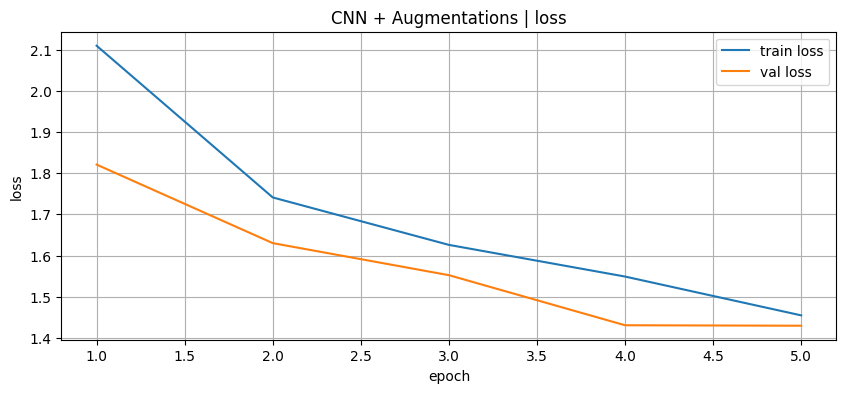

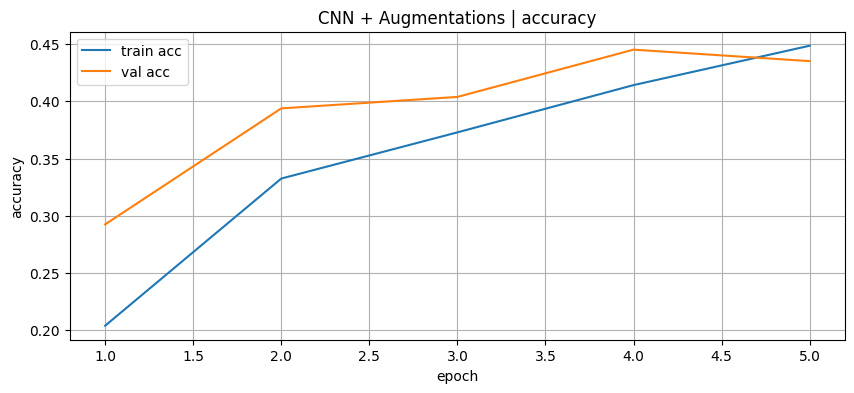

Best val acc: 0.445


In [17]:
# C2: CNN + аугментации
res_cnn_aug = run_experiment(
    "CNN_aug_96", 
    SimpleCNN(NUM_CLASSES), 
    lr=1e-3, 
    epochs=EPOCHS
)
plot_history(res_cnn_aug["history"], title="CNN + Augmentations")
print(f"Best val acc: {res_cnn_aug['best_val_acc']:.3f}")

Trainable params (head-only): 5130

Phase 1: head-only training
Epoch 01/4 | train loss 1.2163, acc 0.690 | val loss 0.5285, acc 0.909 | 57.9s
Epoch 02/4 | train loss 0.4605, acc 0.907 | val loss 0.3268, acc 0.932 | 55.8s
Epoch 03/4 | train loss 0.3274, acc 0.931 | val loss 0.2599, acc 0.935 | 57.2s
Epoch 04/4 | train loss 0.2865, acc 0.928 | val loss 0.2320, acc 0.938 | 57.0s


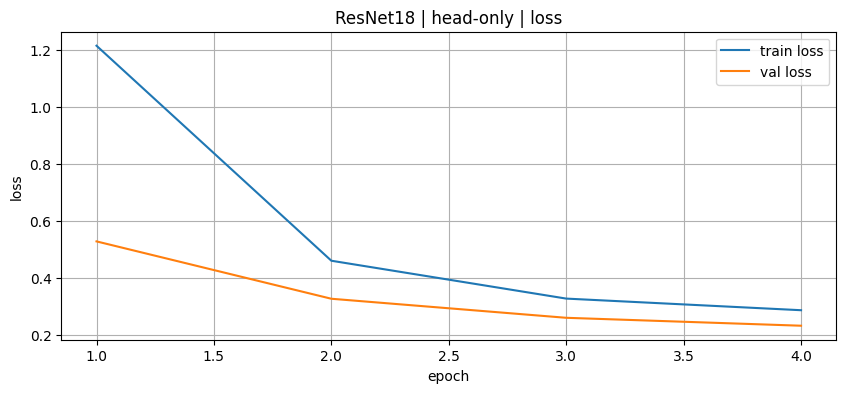

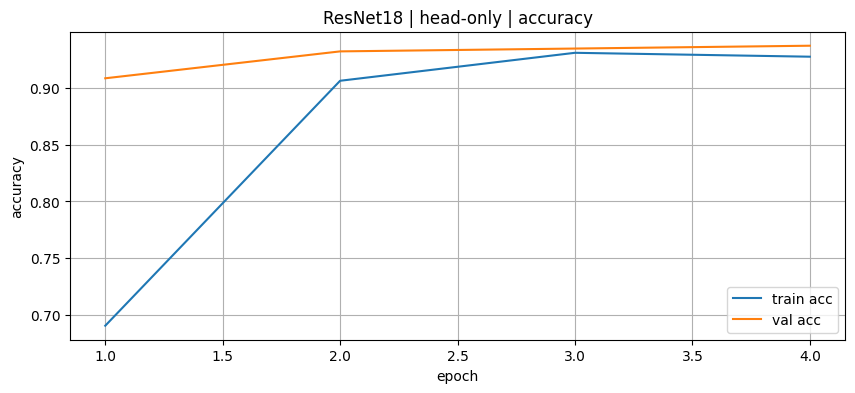

In [18]:
criterion = nn.CrossEntropyLoss()

model_head = build_resnet18(num_classes=10, weights=weights).to(DEVICE)

# freeze всё
set_requires_grad(model_head, False)
# размораживаем только голову
set_requires_grad(model_head.fc, True)

print("Trainable params (head-only):", count_trainable_params(model_head))

optimizer_head = torch.optim.Adam(model_head.fc.parameters(), lr=1e-3)

print("\n" + "=" * 80)
print("Phase 1: head-only training")
hist_head = fit(model_head, train_loader, val_loader, optimizer_head, criterion, epochs=EPOCHS_HEAD, verbose=True)
plot_history(hist_head, title="ResNet18 | head-only")

In [19]:
@torch.no_grad()
def accuracy_on_loader(model, loader) -> float:
    model.eval()
    total_correct, total_seen = 0, 0
    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        logits = model(x)
        total_correct += (torch.argmax(logits, dim=1) == y).sum().item()
        total_seen += y.size(0)
    return total_correct / total_seen

test_acc = accuracy_on_loader(model_head, test_loader)
print("Test acc:", round(test_acc, 4))
     

Test acc: 0.927


Trainable params (layer4+fc): 8398858

Phase 2: fine-tuning layer4 + fc
Epoch 01/4 | train loss 0.2272, acc 0.928 | val loss 0.1546, acc 0.951 | 69.9s
Epoch 02/4 | train loss 0.0810, acc 0.978 | val loss 0.1480, acc 0.948 | 70.1s
Epoch 03/4 | train loss 0.0531, acc 0.986 | val loss 0.1311, acc 0.949 | 69.5s
Epoch 04/4 | train loss 0.0281, acc 0.994 | val loss 0.1463, acc 0.949 | 68.9s


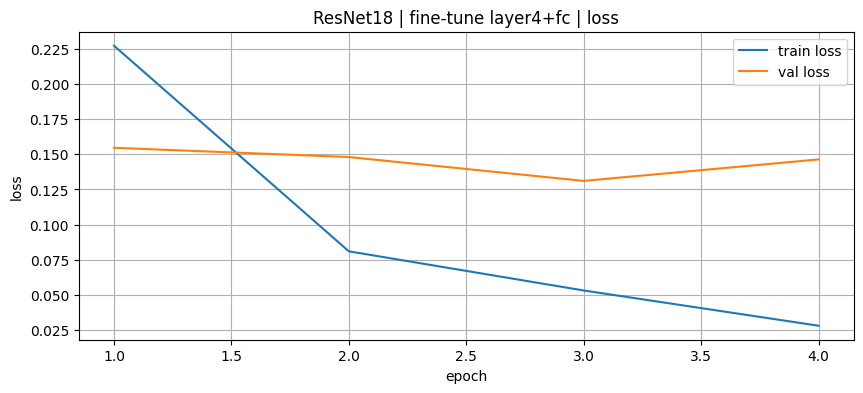

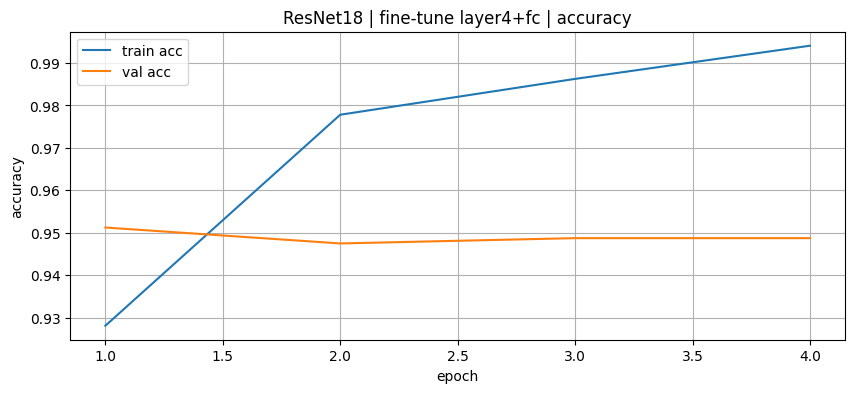

In [20]:
# размораживаем layer4 и fc
set_requires_grad(model_head.layer4, True)
set_requires_grad(model_head.fc, True)

print("Trainable params (layer4+fc):", count_trainable_params(model_head))

# param groups: backbone меньше, head больше
params = [
    {"params": model_head.layer4.parameters(), "lr": 1e-4},
    {"params": model_head.fc.parameters(), "lr": 1e-3},
]

optimizer_ft = torch.optim.Adam(params, weight_decay=1e-4)

print("\n" + "=" * 80)
print("Phase 2: fine-tuning layer4 + fc")
hist_ft = fit(model_head, train_loader, val_loader, optimizer_ft, criterion, epochs=EPOCHS_FT, verbose=True)
plot_history(hist_ft, title="ResNet18 | fine-tune layer4+fc")

B часть

In [21]:
# 5) Модель: DeepLabV3 (COCO-with-VOC-labels) + поиск индекса класса "PET"

import torchvision
from torchvision.models.segmentation import deeplabv3_resnet50, DeepLabV3_ResNet50_Weights

weights = DeepLabV3_ResNet50_Weights.COCO_WITH_VOC_LABELS_V1
model = deeplabv3_resnet50(weights=weights)
model.to(DEVICE)
model.eval()

categories = weights.meta["categories"]
print("Доступные классы:", categories[:10], "..." if len(categories) > 10 else "")

CAT_IDX = categories.index("cat")
DOG_IDX = categories.index("dog")
PET_IDX = min(CAT_IDX, DOG_IDX)  # Используем первый из них для унификации
PET_CLASSES = [CAT_IDX, DOG_IDX]
print("num_classes:", len(categories))
print("CAT_IDX:", CAT_IDX)
print("DOG_IDX:", DOG_IDX)
print("PET_IDX (используемый):", PET_IDX)

# Трансформации, соответствующие весам
preprocess = weights.transforms()
print("Трансформации:", preprocess)
preprocess

Доступные классы: ['__background__', 'aeroplane', 'bicycle', 'bird', 'boat', 'bottle', 'bus', 'car', 'cat', 'chair'] ...
num_classes: 21
CAT_IDX: 8
DOG_IDX: 12
PET_IDX (используемый): 8
Трансформации: SemanticSegmentation(
    resize_size=[520]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)


SemanticSegmentation(
    resize_size=[520]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)

In [22]:
class OxfordPetSegDataset(torch.utils.data.Dataset):
    def __init__(self, root: str):
        self.root = root
        self.img_dir = root  # корневая папка с изображениями
        self.mask_dir = os.path.join(root, "annotations", "trimaps")

        # Список файлов изображений и масок
        img_files = sorted([f for f in os.listdir(self.img_dir)
                            if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
        mask_files = sorted([f for f in os.listdir(self.mask_dir)
                             if f.lower().endswith('.png')])

        # Сопоставление по имени без расширения
        img_stems = {os.path.splitext(f)[0]: f for f in img_files}
        mask_stems = {os.path.splitext(f)[0]: f for f in mask_files}
        common_stems = sorted(set(img_stems.keys()) & set(mask_stems.keys()))

        if not common_stems:
            raise RuntimeError(f"Не найдено пар изображение-маска!\n"
                               f"В {self.img_dir}: {len(img_files)} файлов\n"
                               f"В {self.mask_dir}: {len(mask_files)} файлов")

        self.imgs = [img_stems[s] for s in common_stems]
        self.masks = [mask_stems[s] for s in common_stems]

        print(f"Загружено {len(self.imgs)} пар изображение-маска для сегментации")

    def __len__(self) -> int:
        return len(self.imgs)

    def __getitem__(self, idx: int):
        img_path = os.path.join(self.img_dir, self.imgs[idx])
        mask_path = os.path.join(self.mask_dir, self.masks[idx])

        img = Image.open(img_path).convert("RGB")
        mask = Image.open(mask_path)

        # Преобразуем маску в numpy и создаём бинарную маску питомца
        mask_np = np.array(mask)
        pet_mask = (mask_np == 2).astype(np.uint8)   # 2 – питомец, 1 – фон, 3 – граница
        # Иногда встречаются маски с 1=фон, 2=питомец, 3=граница; берём только 2

        return img, pet_mask
        
dataset = OxfordPetSegDataset(oxford_root)
len(dataset), dataset[0][0].size, dataset[0][1].shape

Загружено 7390 пар изображение-маска для сегментации


(7390, (600, 400), (400, 600))

In [23]:
@torch.no_grad()

def predict_pet_mask(img_pil: Image.Image, confidence_threshold=0.5):
    x = preprocess(img_pil).unsqueeze(0).to(DEVICE)
    out = model(x)["out"][0]           # [21, H, W]
    probs = torch.softmax(out, dim=0)   # [21, H, W]
    # Суммируем вероятности для классов кошки и собаки
    pet_probs = probs[PET_CLASSES].sum(dim=0)  # [H, W]
    pet_mask = pet_probs > confidence_threshold
    return pet_mask.to(torch.uint8).cpu(), x.shape[-2:]

def iou_binary(pred: torch.Tensor, gt: torch.Tensor) -> float:
    pred = pred.bool()
    gt = gt.bool()
    inter = (pred & gt).sum().item()
    union = (pred | gt).sum().item()
    return float(inter / (union + 1e-9))

def eval_subset(indices: List[int]) -> Dict[str, float]:
    ious = []
    for idx in indices:
        img_pil, gt_np = dataset[idx]  # dataset = OxfordPetSegDataset
        pred_mask, (h, w) = predict_pet_mask(img_pil)

        # resize GT to model space (nearest для бинарных масок!)
        gt_pil = Image.fromarray((gt_np * 255).astype(np.uint8))
        gt_rs = F.resize(gt_pil, size=[h, w], interpolation=InterpolationMode.NEAREST)
        gt_mask = (torch.from_numpy(np.array(gt_rs)) > 0).to(torch.uint8)

        ious.append(iou_binary(pred_mask, gt_mask))

    return {
        "n": float(len(ious)),
        "mean_IoU": float(np.mean(ious)),
        "median_IoU": float(np.median(ious)),
        "min_IoU": float(np.min(ious)),
        "max_IoU": float(np.max(ious)),
    }

In [24]:
from torchvision.transforms.functional import to_pil_image, resize
from PIL import Image, ImageDraw
from torchvision.transforms import InterpolationMode

# Функция для визуализации нескольких примеров
def visualize_predictions(num_samples=5, threshold=0.2):
    model.eval()
    indices = np.random.choice(len(dataset), num_samples, replace=False)
    
    fig, axes = plt.subplots(num_samples, 3, figsize=(12, 4*num_samples))
    if num_samples == 1:
        axes = axes.reshape(1, -1)
    
    for i, idx in enumerate(indices):
        img_pil, gt_np = dataset[idx]
        # Предсказание
        pred_mask, (h, w) = predict_pet_mask(img_pil, confidence_threshold=threshold)
        # Преобразуем GT в то же разрешение, что и предсказание (для IoU)
        gt_pil = Image.fromarray((gt_np * 255).astype(np.uint8))
        gt_rs = resize(gt_pil, [h, w], interpolation=InterpolationMode.NEAREST)
        gt_mask = (torch.from_numpy(np.array(gt_rs)) > 0).to(torch.uint8)
        
        # Для визуализации: ресайзим предсказанную маску до размера исходного изображения
        pred_mask_resized = torch.from_numpy(np.array(resize(Image.fromarray((pred_mask.numpy() * 255).astype(np.uint8)), 
                                                           img_pil.size[::-1], interpolation=InterpolationMode.NEAREST)) > 0).to(torch.uint8)
        
        # Вычисляем IoU (по маскам, приведённым к размеру предсказания)
        iou = iou_binary(pred_mask, gt_mask)
        
        # Отображаем исходное изображение
        axes[i, 0].imshow(img_pil)
        axes[i, 0].set_title('Image')
        axes[i, 0].axis('off')
        
        # Предсказанная маска (красный цвет) — теперь на размере исходного изображения
        pred_overlay = img_pil.copy().convert('RGBA')
        pred_overlay = np.array(pred_overlay)
        pred_mask_np = pred_mask_resized.numpy()
        pred_overlay[pred_mask_np == 1, 0] = 255   # R
        pred_overlay[pred_mask_np == 1, 1] = 0     # G
        pred_overlay[pred_mask_np == 1, 2] = 0     # B
        pred_overlay[pred_mask_np == 1, 3] = 128   # alpha
        axes[i, 1].imshow(pred_overlay)
        axes[i, 1].set_title(f'Prediction (IoU={iou:.3f})')
        axes[i, 1].axis('off')
        
        # Истинная маска (зелёный цвет) — тоже ресайзим до размера изображения
        gt_overlay = img_pil.copy().convert('RGBA')
        gt_overlay = np.array(gt_overlay)
        gt_mask_np = np.array(resize(Image.fromarray((gt_np * 255).astype(np.uint8)), img_pil.size[::-1], interpolation=InterpolationMode.NEAREST)) > 0
        gt_overlay[gt_mask_np, 0] = 0
        gt_overlay[gt_mask_np, 1] = 255
        gt_overlay[gt_mask_np, 2] = 0
        gt_overlay[gt_mask_np, 3] = 128
        axes[i, 2].imshow(gt_overlay)
        axes[i, 2].set_title('Ground truth')
        axes[i, 2].axis('off')
    
    plt.tight_layout()
    plt.show()

Baseline (threshold=0.5):
{'n': 73.0, 'mean_IoU': 0.0056591289440508855, 'median_IoU': 8.969988979727797e-05, 'min_IoU': 0.0, 'max_IoU': 0.19455257004438528}

Alternative threshold 0.3:
{'n': 73.0, 'mean_IoU': 0.010228298031900427, 'median_IoU': 0.0007084698344404234, 'min_IoU': 0.0, 'max_IoU': 0.22955991158799097}
Сохранено в artifacts/figures/segmentation_examples.png

--- Summary ---
Threshold 0.5  -> mean IoU: 0.0057
Threshold 0.3  -> mean IoU: 0.0102


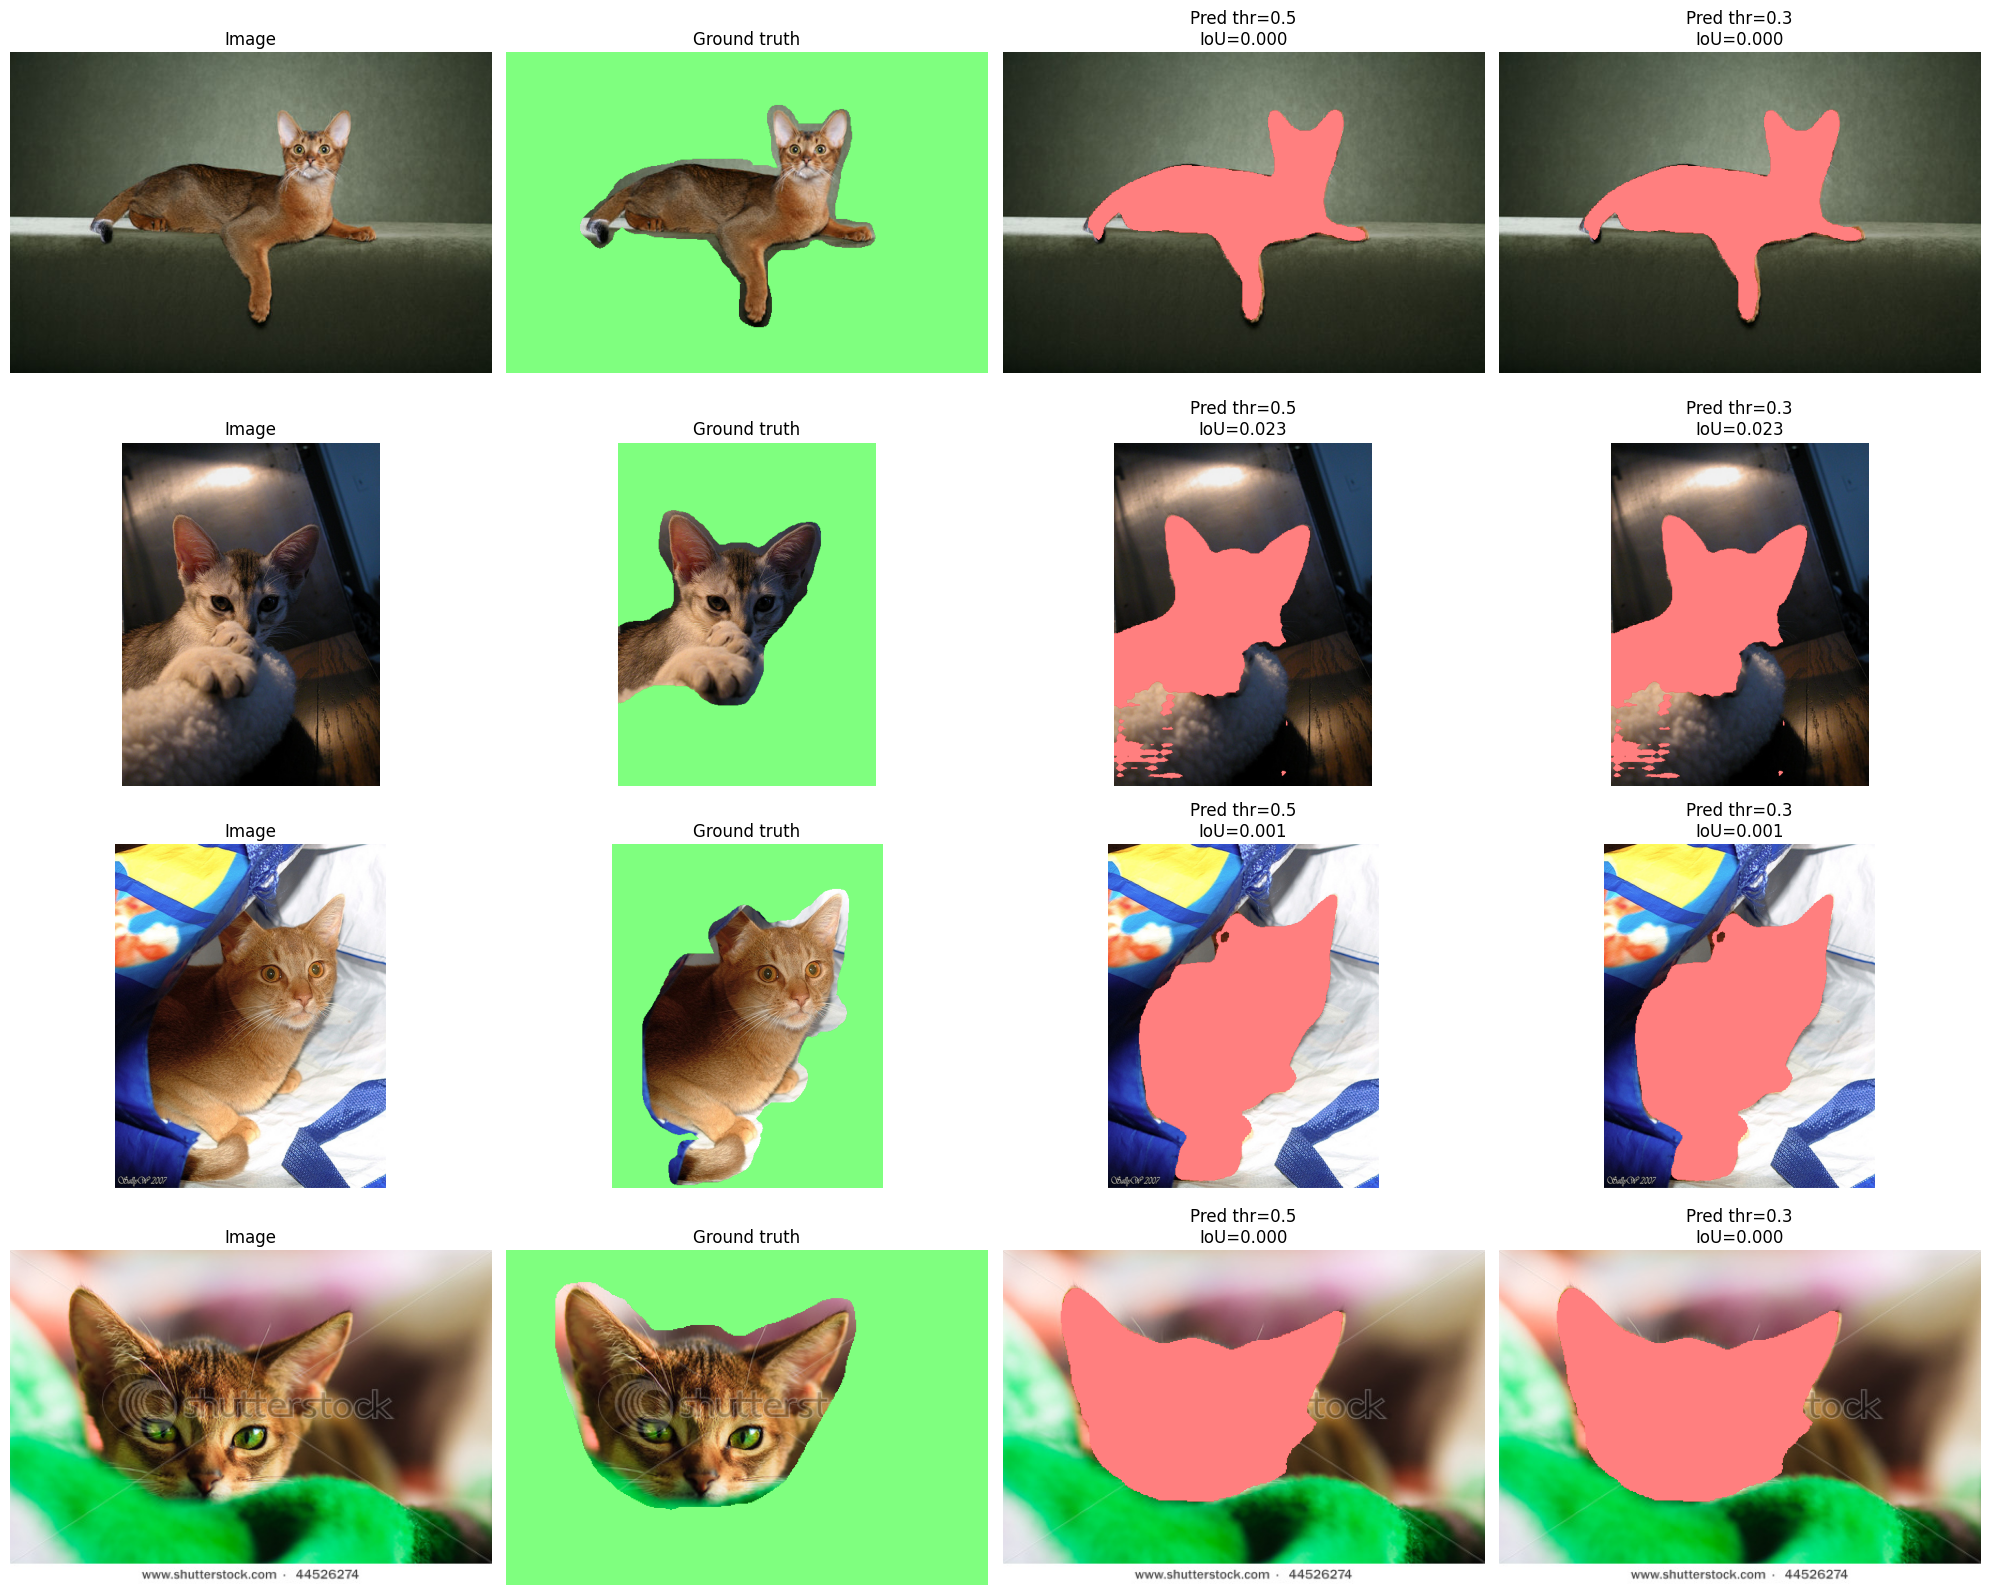

In [25]:
import torchvision.transforms.functional as F
# ---------- Функция для альтернативного порога ----------
def threshold_alternative(mask, threshold=0.3):
    return (mask > threshold).to(torch.uint8)

# ---------- Функция вычисления метрик для подмножества ----------
def eval_subset_with_threshold(indices, threshold=0.5):
    ious = []
    for idx in indices:
        img_pil, gt_np = dataset[idx]
        # предсказание с заданным порогом
        pred_mask, (h, w) = predict_pet_mask(img_pil, confidence_threshold=threshold)
        # GT к размеру предсказания
        gt_pil = Image.fromarray((gt_np * 255).astype(np.uint8))
        gt_rs = resize(gt_pil, [h, w], interpolation=InterpolationMode.NEAREST)
        gt_mask = (torch.from_numpy(np.array(gt_rs)) > 0).to(torch.uint8)
        ious.append(iou_binary(pred_mask, gt_mask))
    return {
        "n": float(len(ious)),
        "mean_IoU": float(np.mean(ious)),
        "median_IoU": float(np.median(ious)),
        "min_IoU": float(np.min(ious)),
        "max_IoU": float(np.max(ious)),
    }

# ---------- Визуализация сравнения порогов (0.5 vs 0.3) с выводом IoU ----------
def visualize_threshold_comparison_with_save(indices, thresholds=[0.5, 0.3], save_path='artifacts/figures/segmentation_examples.png'):
    """
    Для каждого изображения показывает: исходное изображение, GT,
    предсказание с порогом 0.5 и предсказание с порогом 0.3.
    Сохраняет полотно в файл.
    """
    fig, axes = plt.subplots(len(indices), 2 + len(thresholds), 
                             figsize=(5*(2+len(thresholds)), 4*len(indices)))
    if len(indices) == 1:
        axes = axes.reshape(1, -1)
    for i, idx in enumerate(indices):
        img_pil, gt_np = dataset[idx]
        pred_base, (h, w) = predict_pet_mask(img_pil, confidence_threshold=0.5)
        # GT для визуализации
        gt_pil = Image.fromarray((gt_np * 255).astype(np.uint8))
        gt_rs = resize(gt_pil, [h, w], interpolation=InterpolationMode.NEAREST)
        gt_mask = (torch.from_numpy(np.array(gt_rs)) > 0).to(torch.uint8)
        # изображение
        axes[i, 0].imshow(img_pil)
        axes[i, 0].set_title('Image')
        axes[i, 0].axis('off')
        # GT
        gt_overlay = np.array(img_pil.copy().convert('RGBA'))
        gt_np_vis = np.array(resize(Image.fromarray((gt_np * 255).astype(np.uint8)),
                                    img_pil.size[::-1], interpolation=InterpolationMode.NEAREST)) > 0
        gt_overlay[gt_np_vis, 0] = 0
        gt_overlay[gt_np_vis, 1] = 255
        gt_overlay[gt_np_vis, 2] = 0
        gt_overlay[gt_np_vis, 3] = 128
        axes[i, 1].imshow(gt_overlay)
        axes[i, 1].set_title('Ground truth')
        axes[i, 1].axis('off')
        # предсказания с разными порогами
        for j, thr in enumerate(thresholds):
            pred_mask = threshold_alternative(pred_base, threshold=thr)
            iou_val = iou_binary(pred_mask, gt_mask)
            pred_resized = torch.from_numpy(np.array(
                resize(Image.fromarray((pred_mask.cpu().numpy() * 255).astype(np.uint8)),
                       img_pil.size[::-1], interpolation=InterpolationMode.NEAREST)
            ) > 0).to(torch.uint8)
            overlay = np.array(img_pil.copy().convert('RGBA'))
            pred_np = pred_resized.cpu().numpy()
            overlay[pred_np == 1, 0] = 255
            overlay[pred_np == 1, 1] = 0
            overlay[pred_np == 1, 2] = 0
            overlay[pred_np == 1, 3] = 128
            axes[i, 2+j].imshow(overlay)
            axes[i, 2+j].set_title(f'Pred thr={thr}\nIoU={iou_val:.3f}')
            axes[i, 2+j].axis('off')
    plt.tight_layout()
    plt.savefig(save_path)
    print(f"Сохранено в {save_path}")

# ---------- Выбор тестовых индексов ----------
if cfg.fast_mode:
    test_indices = list(range(len(dataset)//100))
else:
    test_indices = list(range(len(dataset)))

# ---------- Базовый порог 0.5 ----------
print("Baseline (threshold=0.5):")
base_metrics = eval_subset(test_indices)
print(base_metrics)

# ---------- Альтернативный порог 0.3 ----------
print("\nAlternative threshold 0.3:")
alt_metrics = eval_subset_with_threshold(test_indices, threshold=0.3)
print(alt_metrics)

# ---------- Визуализация сравнения ----------
visualize_threshold_comparison_with_save(test_indices[:4], thresholds=[0.5, 0.3], save_path='artifacts/figures/segmentation_examples.png')

# ---------- Итоговое сравнение среднего IoU ----------
print("\n--- Summary ---")
print(f"Threshold 0.5  -> mean IoU: {base_metrics['mean_IoU']:.4f}")
print(f"Threshold 0.3  -> mean IoU: {alt_metrics['mean_IoU']:.4f}")

In [26]:
if 'res_cnn' in locals() and 'model' in res_cnn:
    test_acc_cnn = accuracy_on_loader(res_cnn['model'], test_loader)
else:
    test_acc_cnn = None

log_experiment(
    experiment_id='C1',
    task='classification',
    dataset='STL10',
    seed=RANDOM_STATE,
    model_summary='SimpleCNN (3 conv + 2 fc)',
    optimizer='Adam',
    lr=0.001,
    epochs_trained=len(res_cnn['history']['val_acc']) if 'res_cnn' in locals() else None,
    best_val_accuracy=res_cnn['best_val_acc'] if 'res_cnn' in locals() else None,
    test_accuracy=test_acc_cnn,
    notes='простая CNN без аугментаций'
)

if 'res_cnn_aug' in locals():
    test_acc_cnn_aug = accuracy_on_loader(res_cnn_aug['model'], test_loader)
    log_experiment(
        experiment_id='C2',
        task='classification',
        dataset='STL10',
        seed=RANDOM_STATE,
        model_summary='SimpleCNN (3 conv + 2 fc)',
        optimizer='Adam',
        lr=0.001,
        epochs_trained=len(res_cnn_aug['history']['val_acc']),
        best_val_accuracy=res_cnn_aug['best_val_acc'],
        test_accuracy=test_acc_cnn_aug,
        notes='CNN с аугментациями'
    )

if 'model_head' in locals() and 'hist_head' in locals():
    # Вычисляем test accuracy для head-only
    test_acc_head = accuracy_on_loader(model_head, test_loader)
    log_experiment(
        experiment_id='C3',
        task='classification',
        dataset='STL10',
        seed=RANDOM_STATE,
        model_summary='ResNet18 (pretrained)',
        optimizer='Adam',
        lr=1e-3,
        epochs_trained=len(hist_head['val_acc']),
        best_val_accuracy=max(hist_head['val_acc']),
        test_accuracy=test_acc_head,
        notes='только обучение головы (fc)'
    )

if 'model_head' in locals() and 'hist_ft' in locals():
    # test_acc уже вычислен ранее (переменная test_acc)
    test_acc_ft = test_acc if 'test_acc' in locals() else accuracy_on_loader(model_head, test_loader)
    log_experiment(
        experiment_id='C4',
        task='classification',
        dataset='STL10',
        seed=RANDOM_STATE,
        model_summary='ResNet18 (pretrained), layer4+fc',
        optimizer='Adam',
        lr=1e-4,  # условно, для layer4
        epochs_trained=len(hist_ft['val_acc']),
        best_val_accuracy=max(hist_ft['val_acc']),
        test_accuracy=test_acc_ft,
        notes='fine-tuning layer4 и fc'
    )

[C1] Сохранено в runs.csv
[C2] Сохранено в runs.csv


C:\Users\Mi\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\utils\data\dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


[C3] Сохранено в runs.csv
[C4] Сохранено в runs.csv


In [27]:
if 'base_metrics' in locals():
    log_experiment(
        experiment_id='V1',
        task='segmentation',
        dataset='OxfordIIITPet',
        seed=RANDOM_STATE,
        model_summary='DeepLabV3_ResNet50 (COCO)',
        optimizer='-',
        lr=None,
        epochs_trained=None,
        mean_iou=base_metrics['mean_IoU'],
        notes='порог бинаризации 0.5, бинарная маска (cat+dog)'
    )

[V1] Сохранено в runs.csv


C:\Users\Mi\AppData\Local\Temp\ipykernel_39744\4261354937.py:41: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_final = pd.concat([df_existing, df_new], ignore_index=True)


In [28]:
if 'alt_metrics' in locals():
    log_experiment(
        experiment_id='V2',
        task='segmentation',
        dataset='OxfordIIITPet',
        seed=RANDOM_STATE,
        model_summary='DeepLabV3_ResNet50 (COCO)',
        optimizer='-',
        lr=None,
        epochs_trained=None,
        mean_iou=alt_metrics['mean_IoU'],
        notes='порог бинаризации 0.3'
    )


[V2] Сохранено в runs.csv


C:\Users\Mi\AppData\Local\Temp\ipykernel_39744\4261354937.py:41: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_final = pd.concat([df_existing, df_new], ignore_index=True)


In [29]:
# Находим лучшую эпоху по validation accuracy
best_epoch_ft = np.argmax(hist_ft["val_acc"])
best_val_acc_ft = max(hist_ft["val_acc"])
test_acc_ft = accuracy_on_loader(model_head, test_loader)  # уже вычислена ранее

# Сохраняем модель
torch.save({
    'model_state_dict': model_head.state_dict(),
    'best_val_acc': best_val_acc_ft,
    'best_epoch': best_epoch_ft,
    'test_acc': test_acc_ft,
}, 'artifacts/best_classifier.pt')
print("Сохранено best_classifier.pt")

C:\Users\Mi\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\utils\data\dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Сохранено best_classifier.pt


In [30]:
import json

best_config = {
    # Основные параметры
    "dataset": "STL10",
    "task": "classification", 
    "num_classes": 10,
    "architecture": "ResNet18",
    "pretrained": "IMAGENET" if weights else "None",
    
    # Обучение head-only
    "head_only_epochs": EPOCHS_HEAD,
    "head_optimizer": "Adam",
    "head_lr": 0.001,
    
    # Fine-tune
    "finetune_layers": "layer4+fc",
    "finetune_epochs": EPOCHS_FT,
    "finetune_optimizer": "Adam",
    "finetune_lr_layer4": 1e-4,
    "finetune_lr_fc": 1e-3,
    "weight_decay": 1e-4,
    
    # Метрики лучшей модели
    "best_val_accuracy": float(best_val_acc_ft),
    "test_accuracy": float(test_acc_ft),
    "best_epoch": int(best_epoch_ft),
    
    # Воспроизводимость
    "seed": int(RANDOM_STATE),
    "device": str(DEVICE),
    
    "batch_size": 64,
    "transforms": "resnet_transform",  # стандартный STL10 transform
}

with open('artifacts/best_classifier_config.json', 'w') as f:
    json.dump(best_config, f, indent=2)


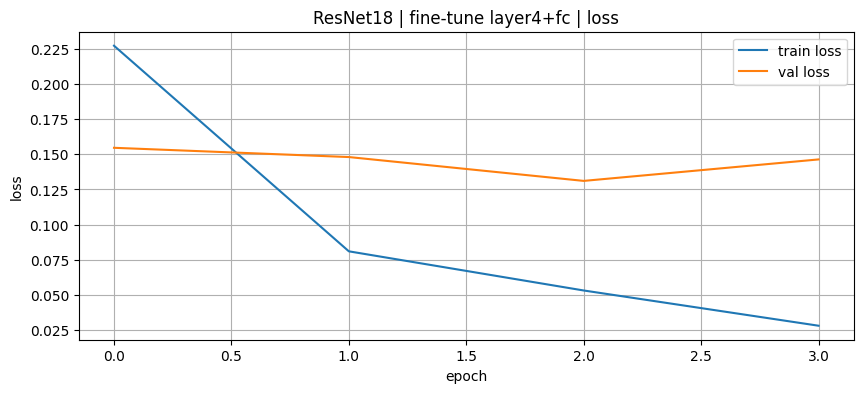

In [31]:
plt.figure(figsize=(10, 4))
plt.plot(hist_ft["train_loss"], label="train loss")
plt.plot(hist_ft["val_loss"], label="val loss")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.title("ResNet18 | fine-tune layer4+fc | loss")
plt.grid(True)
plt.legend()
plt.savefig('artifacts/figures/classification_curves_best.png')

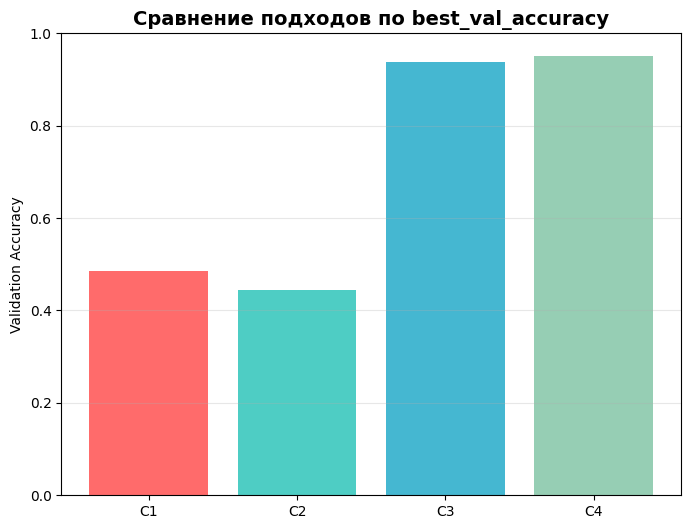

In [32]:
models = ['C1', 'C2', 'C3', 'C4']
accuracies = [
    res_cnn['best_val_acc'],
    res_cnn_aug['best_val_acc'],
    max(hist_head['val_acc']),
    best_val_acc_ft
]
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4']

fig, ax = plt.subplots(1, 1, figsize=(8, 6))
bars = ax.bar(models, accuracies, color=colors)
ax.set_title('Сравнение подходов по best_val_accuracy', fontsize=14, fontweight='bold')
ax.set_ylabel('Validation Accuracy')
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.3, axis='y')
plt.savefig('artifacts/figures/classification_compare.png')

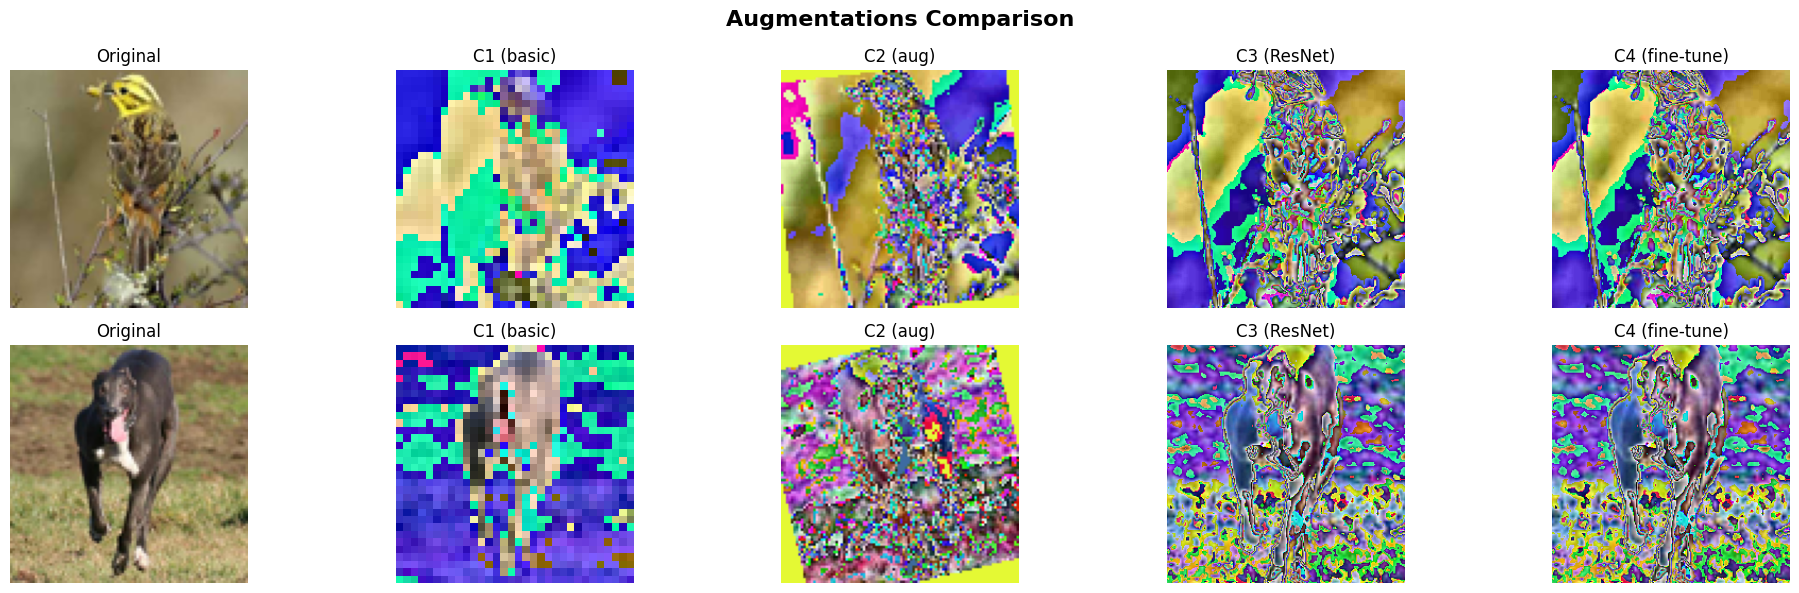

In [33]:
# Создаём словари с датасетами и трансформациями для отображения
# Для C1 используем ds_train_aug (но он с аугментациями) – нужно взять ds_train_eval (без аугментаций)
dataset_c1 = ds_train_eval  # базовый, без аугментаций
dataset_c2 = ds_train_aug   # с аугментациями (но в нём лежат Subset? лучше взять исходный)
# Для C3 (ResNet head-only) и C4 (fine-tune) используем те же датасеты, что и в обучении
# Используем ds_train_aug и ds_train_eval, но с разными трансформациями.
# Для простоты возьмём первые 2 изображения и применим нужные трансформации вручную.

# Трансформации для C1 (базовая) – стандартная для STL10 (resize 32x32)
basic_transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])
# Трансформации для C2 (аугментации) – как в train_tf
train_transform = transforms.Compose([
    transforms.Resize(112),
    transforms.RandomResizedCrop(96, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])
# Трансформации для C3 и C4 (ResNet) – resnet_transform (preprocess)
resnet_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

# Берём 2 изображения из исходного датасета (не из Subset)
# Используем оригинальный ds_train_eval, который содержит полные данные
orig_dataset = torchvision.datasets.STL10(root=DATA_DIR, split='train', download=False, transform=None)
indices = [0, 1]  # два примера

fig, axes = plt.subplots(2, 5, figsize=(20, 6))  # 2 строки, 5 колонок: Original + C1, C2, C3, C4
for row, idx in enumerate(indices):
    img, _ = orig_dataset[idx]  # PIL Image
    # Колонка 0: оригинал
    axes[row, 0].imshow(img)
    axes[row, 0].set_title('Original')
    axes[row, 0].axis('off')
    
    # Колонка 1: C1 (базовая)
    img_c1 = basic_transform(img)
    img_c1 = F.to_pil_image(img_c1)
    axes[row, 1].imshow(img_c1)
    axes[row, 1].set_title('C1 (basic)')
    axes[row, 1].axis('off')
    
    # Колонка 2: C2 (аугментации)
    img_c2 = train_transform(img)
    img_c2 = F.to_pil_image(img_c2)
    axes[row, 2].imshow(img_c2)
    axes[row, 2].set_title('C2 (aug)')
    axes[row, 2].axis('off')
    
    # Колонка 3: C3 (ResNet head-only) – используем resnet_transform
    img_c3 = resnet_transform(img)
    img_c3 = F.to_pil_image(img_c3)
    axes[row, 3].imshow(img_c3)
    axes[row, 3].set_title('C3 (ResNet)')
    axes[row, 3].axis('off')
    
    # Колонка 4: C4 (fine-tune) – та же трансформация
    axes[row, 4].imshow(img_c3)
    axes[row, 4].set_title('C4 (fine-tune)')
    axes[row, 4].axis('off')

plt.suptitle('Augmentations Comparison', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('artifacts/figures/augmentations_preview.png')

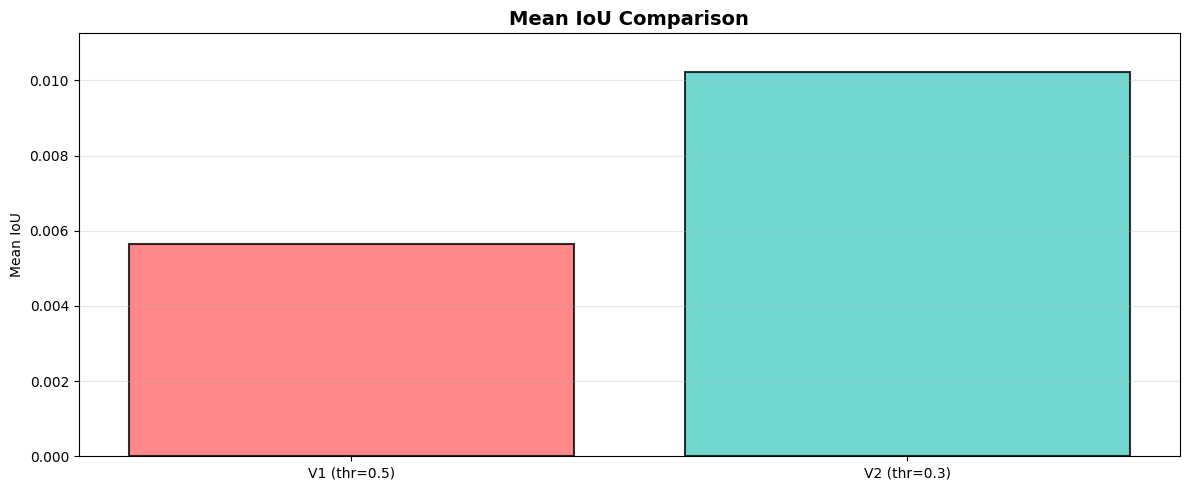

In [34]:
# ========== 6. Сохранение графика сравнения IoU для сегментации ==========
# У нас уже есть переменные base_metrics и alt_metrics из предыдущих ячеек
# Если нет – вычислим заново (на тот же тестовый набор)
if 'base_metrics' not in locals() or 'alt_metrics' not in locals():
    # Пересчитываем на тестовом подмножестве
    if cfg.fast_mode:
        eval_indices = list(range(len(dataset)//100))
    else:
        eval_indices = list(range(len(dataset)))
    base_metrics = eval_subset(eval_indices)
    alt_metrics = eval_subset_with_threshold(eval_indices, threshold=0.3)

fig, ax = plt.subplots(1, 1, figsize=(12, 5))
categories = ['V1 (thr=0.5)', 'V2 (thr=0.3)']
mean_ious = [base_metrics['mean_IoU'], alt_metrics['mean_IoU']]

bars = ax.bar(categories, mean_ious, color=['#FF6B6B', '#4ECDC4'], 
               alpha=0.8, edgecolor='black', linewidth=1.5)
ax.set_title('Mean IoU Comparison', fontsize=14, fontweight='bold')
ax.set_ylabel('Mean IoU')
ax.set_ylim(0, max(mean_ious)*1.1)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('artifacts/figures/segmentation_metrics.png')